<center>

# ***Trabajo Práctico Nro 1 - Continual Learning***

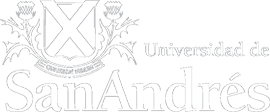

### **Asignatura:** Visión Artificial Avanzada (I309)

### **Alumnos:** Mateo Giacometti y Tiziano Leví Martín Bernal

### **Profesores:** Gastón Castro, Agustín Roca y Francisco Gómez  

### **Fecha:** 30/04/2026

</center>

In [1]:
from pathlib import Path
import math
import sys

import torch
from torch import nn
from torch.utils.data import DataLoader

sys.path.append(str(Path.cwd() / "src"))

from tp1_cl import (
    CIFAR10_CLASSES,
    ContrastiveTaskDataset,
    LabelMapper,
    ReservoirReplayBuffer,
    SeqCIFAR10Builder,
    TaskConfig,
    TransformConfig,
    TwoCropTransform,
    build_cifar_resnet,
    build_transforms,
    ensure_checkpoint_dir,
    load_checkpoint,
    load_config,
    save_checkpoint,
    set_seed,
    train_ewc_method,
    train_linear_head,
    train_naive_finetuning_method,
    train_lwf_method,
    train_co2l_method,
    train_er_ace_method,
    train_supcon,
    plot_forgetting_by_task,
    plot_forgetting_curves,
    plot_methods_over_tasks,
)
from tp1_cl.models import SupConLoss, SupConNetwork
from tp1_cl.viz import (
    plot_cl_metrics,
    plot_embedding_snapshots,
    plot_linear_history,
    plot_supcon_loss,
)

cfg = load_config("configs/cifar10.yaml")
set_seed(int(cfg.training.seed))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

ckpt_dir = ensure_checkpoint_dir(cfg.outputs.checkpoints)

def ckpt(name: str) -> Path:
    return ckpt_dir / name


Using device: cuda


## 4.1 Preparacion del dataset

In [4]:
num_workers = int(cfg.training.num_workers) if torch.cuda.is_available() else min(4, int(cfg.training.num_workers))
dataloader_kwargs = {
    "num_workers": num_workers,
    "pin_memory": torch.cuda.is_available(),
    "persistent_workers": num_workers > 0,
}
if num_workers > 0:
    dataloader_kwargs["prefetch_factor"] = int(cfg.training.dataloader.prefetch_factor)

transform_cfg = TransformConfig(
    mean=tuple(cfg.transforms.mean),
    std=tuple(cfg.transforms.std),
    crop_size=int(cfg.transforms.crop_size),
    crop_scale=tuple(cfg.transforms.crop_scale),
    hflip_prob=float(cfg.transforms.hflip_prob),
    color_jitter_values=tuple(cfg.transforms.color_jitter_values),
    color_jitter_prob=float(cfg.transforms.color_jitter_prob),
    grayscale_prob=float(cfg.transforms.grayscale_prob),
)
eval_transform, supcon_train_transform = build_transforms(transform_cfg)

task_cfg = TaskConfig(
    n_tasks=int(cfg.data.n_tasks),
    classes_per_task=int(cfg.data.classes_per_task),
    class_order=list(cfg.data.class_order),
    shuffle_class_order=False,
    seed=int(cfg.training.seed),
)
seq_builder = SeqCIFAR10Builder(root=cfg.data.root, config=task_cfg)

task_train_loaders, task_test_loaders = seq_builder.build_task_loaders(
    batch_size=int(cfg.training.batch_size),
    transform=eval_transform,
    train_shuffle=True,
    num_workers=num_workers,
    loader_kwargs=dataloader_kwargs,
)

print("4.1 | Seq-CIFAR-10 split summary")
for row in seq_builder.summary_rows():
    print(
        f"Task {row['task_id']}: classes={row['class_names']} | train={row['n_train']} | test={row['n_test']}"
    )

replay_buffer = ReservoirReplayBuffer(capacity=int(cfg.data.buffer_size), seed=int(cfg.training.seed))
demo_images, demo_labels = next(iter(task_train_loaders[0]))
replay_buffer.add(demo_images, demo_labels)
sample_images, sample_labels = replay_buffer.sample(batch_size=16)
print(
    f"Replay buffer size={len(replay_buffer)} / {int(cfg.data.buffer_size)} | sample={sample_images.shape}, labels={sample_labels.shape}"
)


4.1 | Seq-CIFAR-10 split summary
Task 0: classes=['airplane', 'automobile'] | train=10000 | test=2000
Task 1: classes=['bird', 'cat'] | train=10000 | test=2000
Task 2: classes=['deer', 'dog'] | train=10000 | test=2000
Task 3: classes=['frog', 'horse'] | train=10000 | test=2000
Task 4: classes=['ship', 'truck'] | train=10000 | test=2000
Replay buffer size=200 / 200 | sample=torch.Size([16, 3, 32, 32]), labels=torch.Size([16])


## 4.2 Pre-entrenamiento SupCon

Loaded checkpoint: outputs/checkpoints/task0_supcon.pt


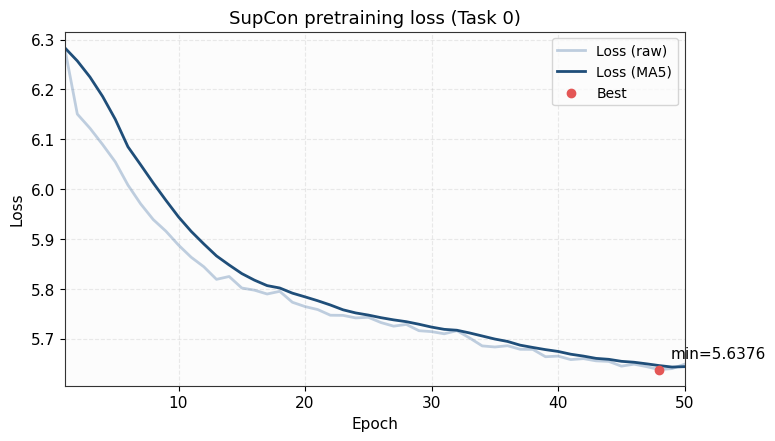

/home/mateo/miniconda3/envs/workspace/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/mateo/miniconda3/envs/workspace/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/mateo/miniconda3/envs/workspace/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/mateo/miniconda3/envs/workspace/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/mateo/miniconda3/envs/workspace/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/mateo/miniconda3/envs/workspa

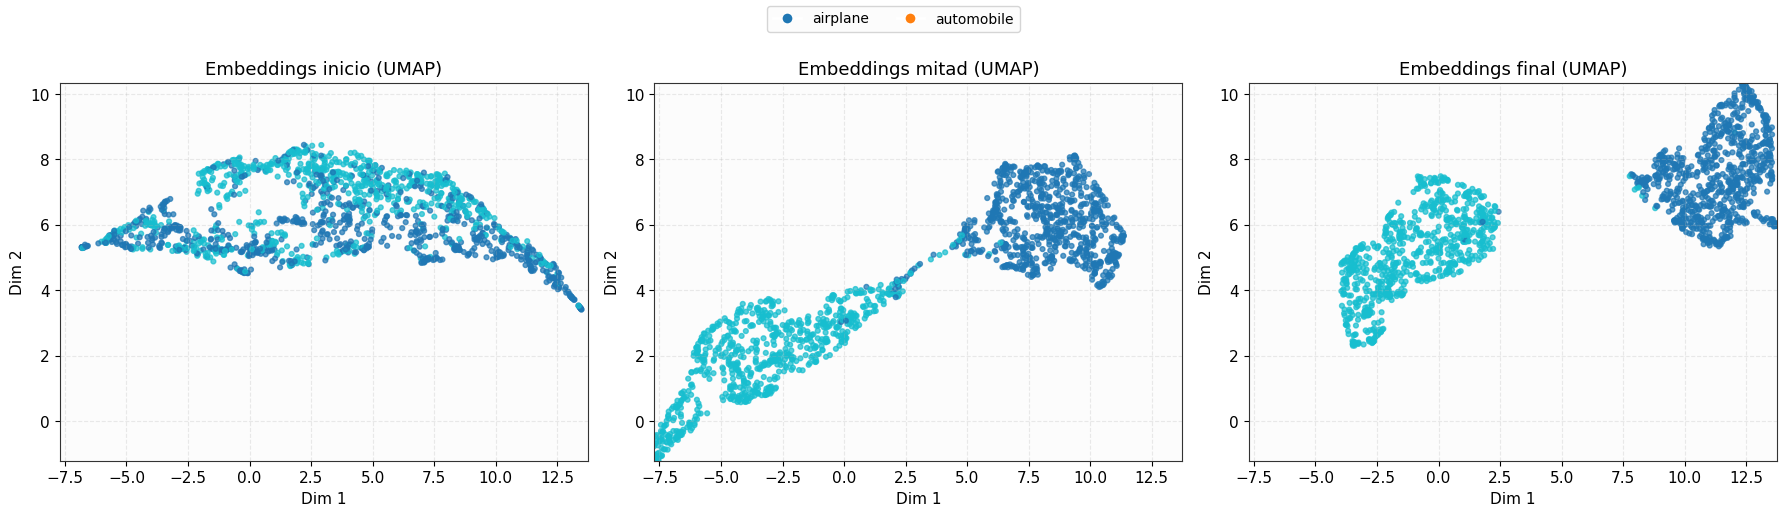

In [5]:
task0_classes = seq_builder.task_classes[0]
task0_class_names = [CIFAR10_CLASSES[c] for c in task0_classes]

task0_train_raw = seq_builder.get_task_dataset(task_id=0, train=True, transform=None)
task0_contrastive_ds = ContrastiveTaskDataset(
    task_dataset=task0_train_raw,
    two_crop_transform=TwoCropTransform(supcon_train_transform),
)
task0_contrastive_loader = DataLoader(
    task0_contrastive_ds,
    batch_size=int(cfg.training.batch_size),
    shuffle=True,
    drop_last=True,
    **dataloader_kwargs,
)

task0_eval_loader = DataLoader(
    seq_builder.get_task_dataset(task_id=0, train=False, transform=eval_transform),
    batch_size=int(cfg.training.batch_size),
    shuffle=False,
    **dataloader_kwargs,
)

backbone, feat_dim = build_cifar_resnet(model_name="resnet18")
supcon_model = SupConNetwork(
    backbone=backbone,
    feat_dim=feat_dim,
    proj_dim=int(cfg.supcon.proj_dim),
).to(device)
supcon_criterion = SupConLoss(
    temperature=float(cfg.supcon.temperature),
    base_temperature=float(cfg.supcon.base_temperature),
)
supcon_optimizer = torch.optim.SGD(
    supcon_model.parameters(),
    lr=float(cfg.supcon.lr),
    momentum=float(cfg.supcon.momentum),
    weight_decay=float(cfg.supcon.weight_decay),
)

supcon_epochs = int(cfg.supcon.epochs)
warmup_epochs = int(cfg.supcon.warmup_epochs)

def supcon_lr_lambda(epoch: int) -> float:
    if epoch < warmup_epochs:
        return float(epoch + 1) / float(max(1, warmup_epochs))
    if supcon_epochs == warmup_epochs:
        return 1.0
    progress = float(epoch - warmup_epochs) / float(supcon_epochs - warmup_epochs)
    return 0.5 * (1.0 + math.cos(math.pi * progress))

supcon_scheduler = torch.optim.lr_scheduler.LambdaLR(
    supcon_optimizer, lr_lambda=supcon_lr_lambda
)

snapshot_epochs = {max(1, supcon_epochs // 2): "mitad", supcon_epochs: "final"}
supcon_ckpt = ckpt("task0_supcon.pt")

if supcon_ckpt.exists():
    payload = load_checkpoint(supcon_ckpt, map_location=device)
    supcon_model.load_state_dict(payload["model"])
    supcon_losses = payload["losses"]
    embedding_snapshots = payload["snapshots"]
    print(f"Loaded checkpoint: {supcon_ckpt}")
else:
    supcon_losses, embedding_snapshots = train_supcon(
        model=supcon_model,
        train_loader=task0_contrastive_loader,
        eval_loader_for_snapshots=task0_eval_loader,
        criterion=supcon_criterion,
        optimizer=supcon_optimizer,
        device=device,
        epochs=supcon_epochs,
        snapshot_epochs=snapshot_epochs,
        scheduler=supcon_scheduler,
    )
    save_checkpoint(
        supcon_ckpt,
        {
            "model": supcon_model.state_dict(),
            "losses": supcon_losses,
            "snapshots": embedding_snapshots,
        },
    )
    print(f"Saved checkpoint: {supcon_ckpt}")

plot_supcon_loss(supcon_losses, save_path=Path(cfg.outputs.root) / "imgs" / "supcon_loss.png")
plot_embedding_snapshots(
    snapshots=embedding_snapshots,
    task_classes=task0_classes,
    class_names=task0_class_names,
    seed=int(cfg.training.seed),
    save_path=Path(cfg.outputs.root) / "imgs" / "embedding_snapshots.png",
)


Loaded checkpoint: outputs/checkpoints/task0_linear_eval.pt


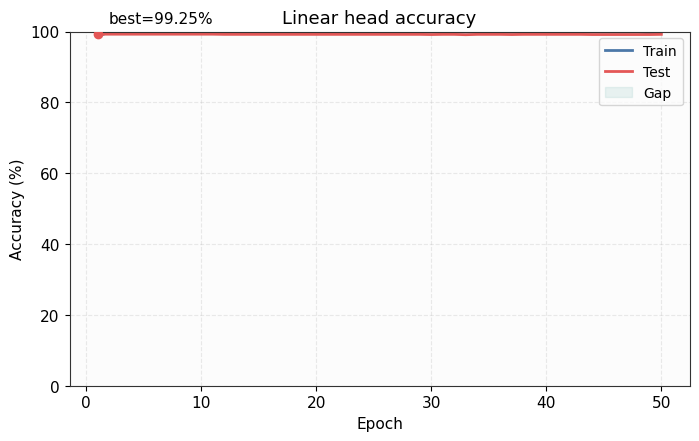

Best Task 0 test accuracy (linear): 99.25%
Final Task 0 test accuracy (linear): 99.20%


In [6]:
label_mapper_task0 = LabelMapper(task_classes=task0_classes)
task0_train_linear = seq_builder.get_task_dataset(
    task_id=0, train=True, transform=eval_transform, target_transform=label_mapper_task0
)
task0_test_linear = seq_builder.get_task_dataset(
    task_id=0, train=False, transform=eval_transform, target_transform=label_mapper_task0
)

task0_train_linear_loader = DataLoader(
    task0_train_linear,
    batch_size=int(cfg.training.batch_size),
    shuffle=True,
    **dataloader_kwargs,
)
task0_test_linear_loader = DataLoader(
    task0_test_linear,
    batch_size=int(cfg.training.batch_size),
    shuffle=False,
    **dataloader_kwargs,
)

linear_head = nn.Linear(feat_dim, len(task0_classes)).to(device)
linear_ckpt = ckpt("task0_linear_eval.pt")

if linear_ckpt.exists():
    payload = load_checkpoint(linear_ckpt, map_location=device)
    linear_head.load_state_dict(payload["linear_head"])
    linear_history = payload["history"]
    task0_best_test_accuracy = payload["best_test_acc"]
    print(f"Loaded checkpoint: {linear_ckpt}")
else:
    linear_history, task0_best_test_accuracy = train_linear_head(
        backbone=supcon_model.backbone,
        linear_head=linear_head,
        train_loader=task0_train_linear_loader,
        test_loader=task0_test_linear_loader,
        device=device,
        epochs=int(cfg.linear_eval.epochs),
        lr=float(cfg.linear_eval.lr),
        scheduler_milestones=list(cfg.linear_eval.milestones),
        scheduler_gamma=float(cfg.linear_eval.gamma),
        report_best=True,
    )
    save_checkpoint(
        linear_ckpt,
        {
            "linear_head": linear_head.state_dict(),
            "history": linear_history,
            "best_test_acc": task0_best_test_accuracy,
        },
    )
    print(f"Saved checkpoint: {linear_ckpt}")

plot_linear_history(linear_history, save_path=Path(cfg.outputs.root) / "imgs" / "linear_eval_accuracy.png")
print(f"Best Task 0 test accuracy (linear): {task0_best_test_accuracy:.2f}%")
print(f"Final Task 0 test accuracy (linear): {linear_history['test_acc'][-1]:.2f}%")


## 4.3.1 Fine-Tuning Naive

Loaded checkpoint: outputs/checkpoints/naive_seq_cifar10.pt


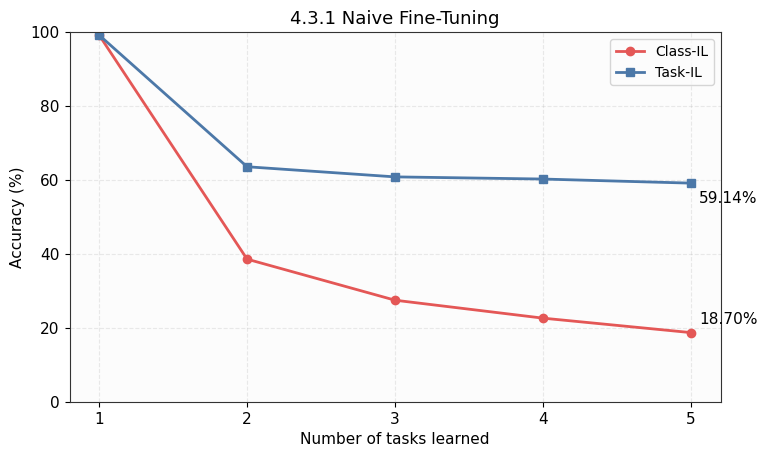

Naive final Class-IL: 18.70%
Naive final Task-IL: 59.14%


In [7]:
naive_ckpt = ckpt("naive_seq_cifar10.pt")

if naive_ckpt.exists():
    payload = load_checkpoint(naive_ckpt, map_location=device)
    naive_history = payload["history"]
    print(f"Loaded checkpoint: {naive_ckpt}")
else:
    naive_model, naive_history = train_naive_finetuning_method(
        backbone=supcon_model.backbone,
        feat_dim=feat_dim,
        train_loaders=task_train_loaders,
        test_loaders=task_test_loaders,
        task_classes=seq_builder.task_classes,
        device=device,
        num_classes=len(CIFAR10_CLASSES),
        epochs_per_task=int(cfg.finetuning.epochs_per_task),
        lr=float(cfg.finetuning.lr),
        momentum=float(cfg.finetuning.momentum),
        weight_decay=float(cfg.finetuning.weight_decay),
        verbose=True,
    )
    save_checkpoint(
        naive_ckpt,
        {
            "model": naive_model.state_dict(),
            "history": naive_history,
        },
    )
    print(f"Saved checkpoint: {naive_ckpt}")

plot_cl_metrics(naive_history, title="4.3.1 Naive Fine-Tuning", save_path=Path(cfg.outputs.root) / "imgs" / "naive_cl_metrics.png")
print(f"Naive final Class-IL: {naive_history['class_il'][-1]:.2f}%")
print(f"Naive final Task-IL: {naive_history['task_il'][-1]:.2f}%")


## 4.3.2 Elastic Weight Consolidation (EWC)

Loaded checkpoint: outputs/checkpoints/ewc_seq_cifar10.pt


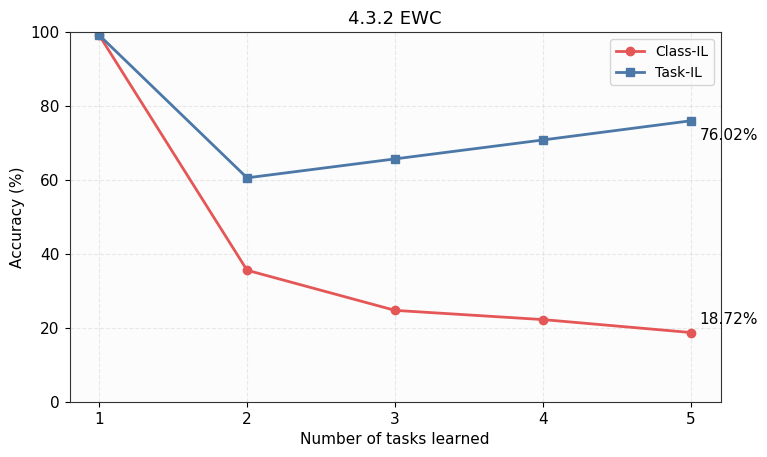

EWC final Class-IL: 18.72%
EWC final Task-IL: 76.02%


In [11]:
ewc_ckpt = ckpt("ewc_seq_cifar10.pt")

if ewc_ckpt.exists():
    payload = load_checkpoint(ewc_ckpt, map_location=device)
    ewc_history = payload["history"]
    print(f"Loaded checkpoint: {ewc_ckpt}")
else:
    ewc_model, ewc_history = train_ewc_method(
        backbone=supcon_model.backbone,
        feat_dim=feat_dim,
        train_loaders=task_train_loaders,
        test_loaders=task_test_loaders,
        task_classes=seq_builder.task_classes,
        device=device,
        num_classes=len(CIFAR10_CLASSES),
        epochs_per_task=int(cfg.ewc.epochs_per_task),
        lr=float(cfg.ewc.lr),
        momentum=float(cfg.ewc.momentum),
        weight_decay=float(cfg.ewc.weight_decay),
        ewc_lambda=float(cfg.ewc.lambda_ewc),
        fisher_max_batches=int(cfg.ewc.fisher_max_batches),
        verbose=True,
    )
    save_checkpoint(
        ewc_ckpt,
        {
            "model": ewc_model.state_dict(),
            "history": ewc_history,
        },
    )
    print(f"Saved checkpoint: {ewc_ckpt}")

plot_cl_metrics(ewc_history, title="4.3.2 EWC", save_path=Path(cfg.outputs.root) / "imgs" / "ewc_cl_metrics.png")
print(f"EWC final Class-IL: {ewc_history['class_il'][-1]:.2f}%")
print(f"EWC final Task-IL: {ewc_history['task_il'][-1]:.2f}%")


## 4.3.3 Learning without Forgetting (LwF)

Loaded checkpoint: outputs/checkpoints/lwf_seq_cifar10.pt


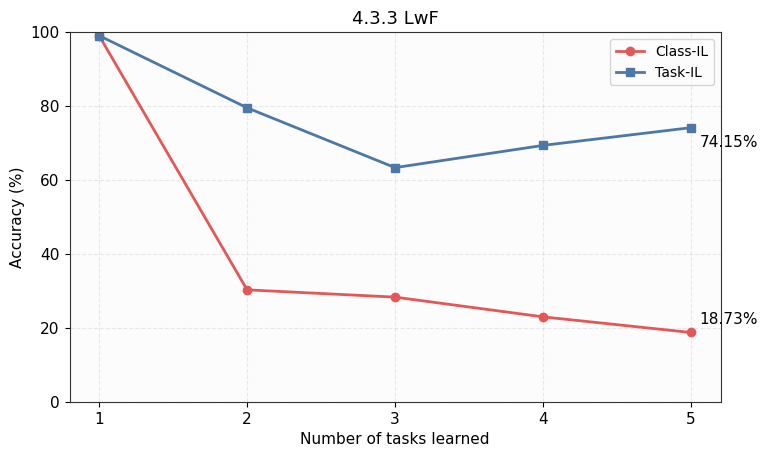

LwF final Class-IL: 18.73%
LwF final Task-IL: 74.15%


In [12]:
lwf_ckpt = ckpt("lwf_seq_cifar10.pt")



if lwf_ckpt.exists():

    payload = load_checkpoint(lwf_ckpt, map_location=device)

    lwf_history = payload["history"]

    print(f"Loaded checkpoint: {lwf_ckpt}")

else:

    lwf_model, lwf_history = train_lwf_method(

        backbone=supcon_model.backbone,

        feat_dim=feat_dim,

        train_loaders=task_train_loaders,

        test_loaders=task_test_loaders,

        task_classes=seq_builder.task_classes,

        device=device,

        num_classes=len(CIFAR10_CLASSES),

        epochs_per_task=int(cfg.lwf.epochs_per_task),

        lr=float(cfg.lwf.lr),

        momentum=float(cfg.lwf.momentum),

        weight_decay=float(cfg.lwf.weight_decay),

        temperature=float(cfg.lwf.temperature),

        alpha=float(cfg.lwf.alpha),

        verbose=True,

    )

    save_checkpoint(

        lwf_ckpt,

        {

            "model": lwf_model.state_dict(),

            "history": lwf_history,

        },

    )

    print(f"Saved checkpoint: {lwf_ckpt}")



plot_cl_metrics(

    lwf_history,

    title="4.3.3 LwF",

    save_path=Path(cfg.outputs.root) / "imgs" / "lwf_cl_metrics.png",

)

print(f"LwF final Class-IL: {lwf_history['class_il'][-1]:.2f}%")

print(f"LwF final Task-IL: {lwf_history['task_il'][-1]:.2f}%")


## 4.3.4 Contrastive Continual Learning (Co2L)

Co2L | Task 0 | Epoch 010/50 | loss=5.6309 | ird=0.0000
Co2L | Task 0 | Epoch 020/50 | loss=5.5016 | ird=0.0000
Co2L | Task 0 | Epoch 030/50 | loss=5.4989 | ird=0.0000
Co2L | Task 0 | Epoch 040/50 | loss=5.4943 | ird=0.0000
Co2L | Task 0 | Epoch 050/50 | loss=5.4917 | ird=0.0000
Task 0 done (Co2L) | Class-IL=98.45% | Task-IL=98.45%
Co2L | Task 1 | Epoch 010/50 | loss=12.1442 | ird=5.7617
Co2L | Task 1 | Epoch 020/50 | loss=12.0521 | ird=5.7561
Co2L | Task 1 | Epoch 030/50 | loss=11.9273 | ird=5.6794
Co2L | Task 1 | Epoch 040/50 | loss=11.8387 | ird=5.5893
Co2L | Task 1 | Epoch 050/50 | loss=11.8233 | ird=5.5643
Task 1 done (Co2L) | Class-IL=74.30% | Task-IL=90.97%
Co2L | Task 2 | Epoch 010/50 | loss=10.8982 | ird=4.5783
Co2L | Task 2 | Epoch 020/50 | loss=10.4563 | ird=4.1807
Co2L | Task 2 | Epoch 030/50 | loss=10.1832 | ird=3.9336
Co2L | Task 2 | Epoch 040/50 | loss=10.0476 | ird=3.8014
Co2L | Task 2 | Epoch 050/50 | loss=10.0193 | ird=3.7783
Task 2 done (Co2L) | Class-IL=55.45% | Tas

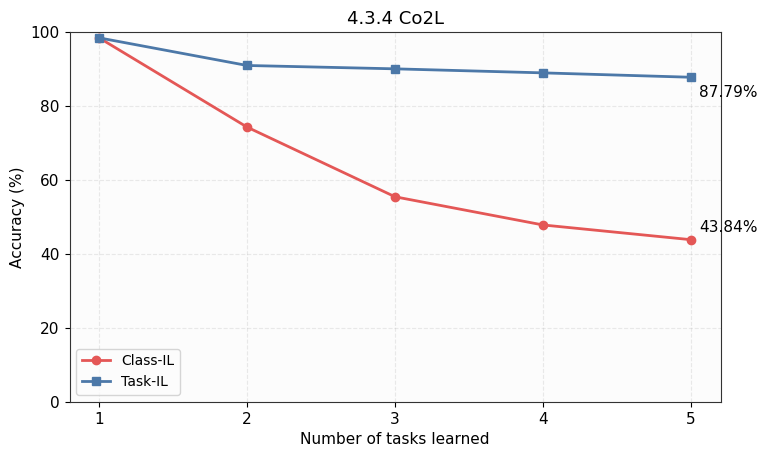

Co2L final Class-IL: 43.84%
Co2L final Task-IL: 87.79%


In [8]:
co2l_ckpt = ckpt("co2l_seq_cifar10.pt")

if co2l_ckpt.exists():
    payload = load_checkpoint(co2l_ckpt, map_location=device)
    co2l_history = payload["history"]
    print(f"Loaded checkpoint: {co2l_ckpt}")
else:
    co2l_model, co2l_history = train_co2l_method(
        backbone=supcon_model.backbone,
        feat_dim=feat_dim,
        train_loaders=task_train_loaders,
        train_loaders_eval=task_train_loaders,
        test_loaders=task_test_loaders,
        task_classes=seq_builder.task_classes,
        device=device,
        num_classes=len(CIFAR10_CLASSES),
        proj_dim=int(cfg.supcon.proj_dim),
        buffer_size=int(cfg.data.buffer_size),
        lr=float(cfg.co2l.lr),
        momentum=float(cfg.co2l.momentum),
        weight_decay=float(cfg.co2l.weight_decay),
        temperature=float(cfg.co2l.temperature),
        kappa=float(cfg.co2l.kappa),
        kappa_star=float(cfg.co2l.kappa_star),
        lambda_ird=float(cfg.co2l.lambda_ird),
        warmup_epochs=int(cfg.co2l.warmup_epochs),
        epochs_task0=int(cfg.co2l.epochs_task0),
        epochs_per_task=int(cfg.co2l.epochs_per_task),
        eval_linear_epochs=int(cfg.co2l.eval_linear_epochs),
        eval_linear_lr=float(cfg.co2l.eval_linear_lr),
        eval_linear_milestones=list(cfg.co2l.eval_linear_milestones),
        eval_linear_gamma=float(cfg.co2l.eval_linear_gamma),
        seed=int(cfg.training.seed),
        max_replay_batch_size=int(cfg.co2l.max_replay_batch_size),
        verbose=True,
    )
    save_checkpoint(
        co2l_ckpt,
        {
            "model": co2l_model.state_dict(),
            "history": co2l_history,
        },
    )
    print(f"Saved checkpoint: {co2l_ckpt}")

plot_cl_metrics(
    co2l_history,
    title="4.3.4 Co2L",
    save_path=Path(cfg.outputs.root) / "imgs" / "co2l_cl_metrics.png",
)
print(f"Co2L final Class-IL: {co2l_history['class_il'][-1]:.2f}%")
print(f"Co2L final Task-IL: {co2l_history['task_il'][-1]:.2f}%")


## [Opcional] ER-ACE (Experience Replay with Asymmetric Cross-Entropy)

ER-ACE | Task 0 | Epoch 01/50 | loss=0.0482 | incoming=0.0482 | replay=0.0000
ER-ACE | Task 0 | Epoch 02/50 | loss=0.0080 | incoming=0.0080 | replay=0.0000
ER-ACE | Task 0 | Epoch 03/50 | loss=0.0083 | incoming=0.0083 | replay=0.0000
ER-ACE | Task 0 | Epoch 04/50 | loss=0.0073 | incoming=0.0073 | replay=0.0000
ER-ACE | Task 0 | Epoch 05/50 | loss=0.0081 | incoming=0.0081 | replay=0.0000
ER-ACE | Task 0 | Epoch 06/50 | loss=0.0089 | incoming=0.0089 | replay=0.0000
ER-ACE | Task 0 | Epoch 07/50 | loss=0.0074 | incoming=0.0074 | replay=0.0000
ER-ACE | Task 0 | Epoch 08/50 | loss=0.0067 | incoming=0.0067 | replay=0.0000
ER-ACE | Task 0 | Epoch 09/50 | loss=0.0060 | incoming=0.0060 | replay=0.0000
ER-ACE | Task 0 | Epoch 10/50 | loss=0.0066 | incoming=0.0066 | replay=0.0000
ER-ACE | Task 0 | Epoch 11/50 | loss=0.0072 | incoming=0.0072 | replay=0.0000
ER-ACE | Task 0 | Epoch 12/50 | loss=0.0075 | incoming=0.0075 | replay=0.0000
ER-ACE | Task 0 | Epoch 13/50 | loss=0.0062 | incoming=0.0062 | 

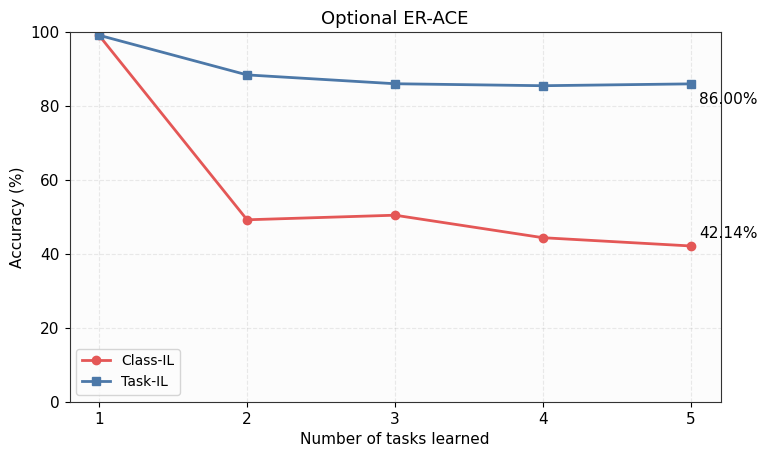

ER-ACE final Class-IL: 42.14%
ER-ACE final Task-IL: 86.00%


In [ ]:
er_ace_ckpt = ckpt("er_ace_seq_cifar10.pt")

if er_ace_ckpt.exists():
    payload = load_checkpoint(er_ace_ckpt, map_location=device)
    er_ace_history = payload["history"]
    print(f"Loaded checkpoint: {er_ace_ckpt}")
else:
    er_ace_model, er_ace_history = train_er_ace_method(
        backbone=supcon_model.backbone,
        feat_dim=feat_dim,
        train_loaders=task_train_loaders,
        test_loaders=task_test_loaders,
        task_classes=seq_builder.task_classes,
        device=device,
        num_classes=len(CIFAR10_CLASSES),
        epochs_per_task=int(cfg.er_ace.epochs_per_task),
        lr=float(cfg.er_ace.lr),
        momentum=float(cfg.er_ace.momentum),
        weight_decay=float(cfg.er_ace.weight_decay),
        buffer_size=int(cfg.data.buffer_size),
        replay_batch_size=int(cfg.er_ace.replay_batch_size),
        incoming_weight=float(cfg.er_ace.incoming_weight),
        replay_weight=float(cfg.er_ace.replay_weight),
        seed=int(cfg.training.seed),
        verbose=True,
    )
    save_checkpoint(
        er_ace_ckpt,
        {
            "model": er_ace_model.state_dict(),
            "history": er_ace_history,
        },
    )
    print(f"Saved checkpoint: {er_ace_ckpt}")

plot_cl_metrics(
    er_ace_history,
    title="Optional ER-ACE",
    save_path=Path(cfg.outputs.root) / "imgs" / "er_ace_cl_metrics.png",
)
print(f"ER-ACE final Class-IL: {er_ace_history['class_il'][-1]:.2f}%")
print(f"ER-ACE final Task-IL: {er_ace_history['task_il'][-1]:.2f}%")


## 4.4 Comparativa final de metodos

Comparativa final (ordenado por Class-IL):
--------------------------------------------------------
Metodo           Class-IL      Task-IL
--------------------------------------------------------
Co2L               43.84%       87.79%
Naive              18.70%       59.14%
Saved metrics table: outputs/metrics/methods_comparison.csv


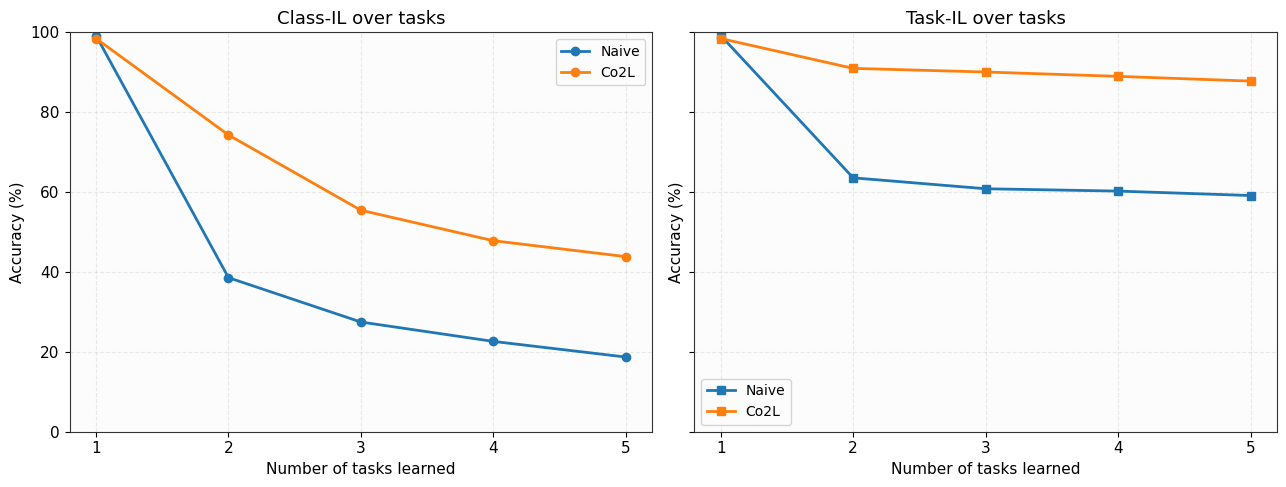

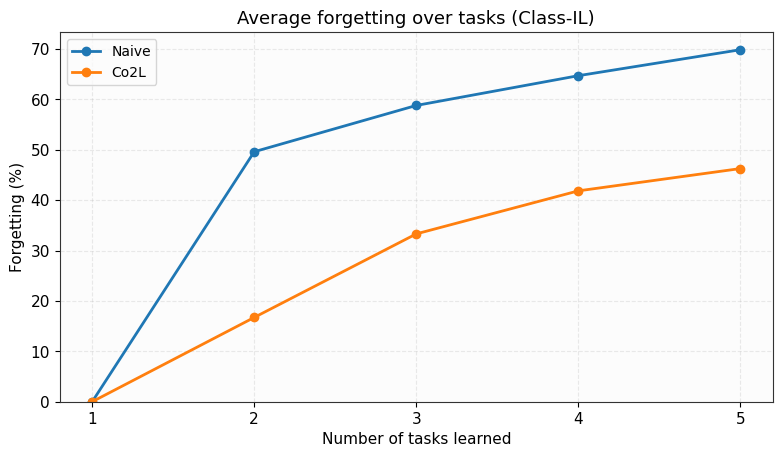

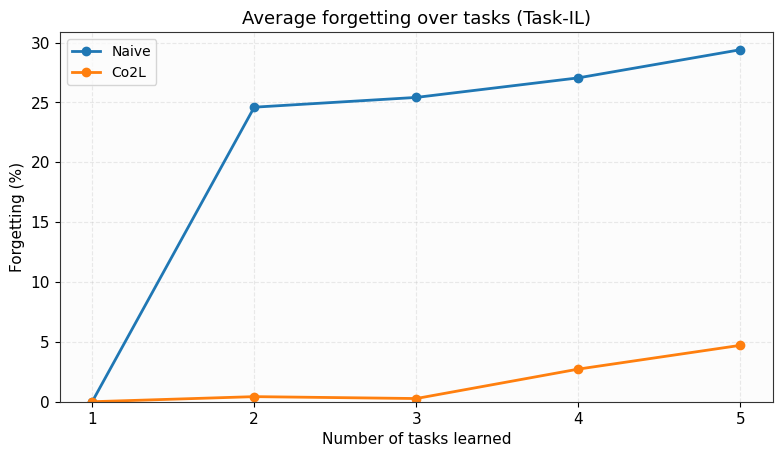

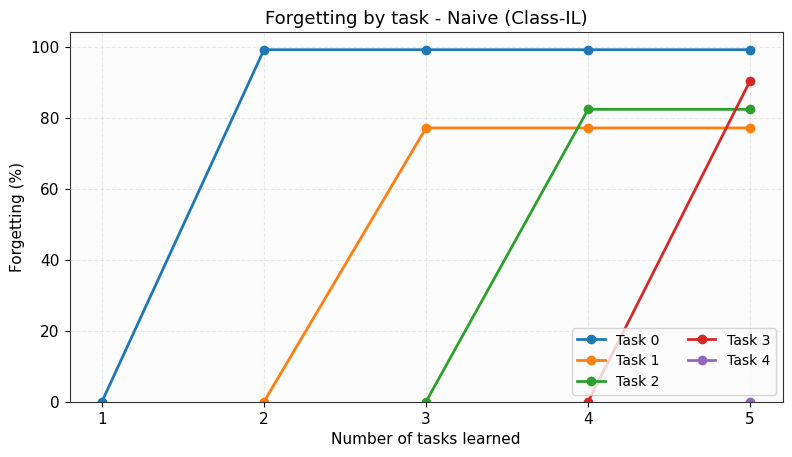

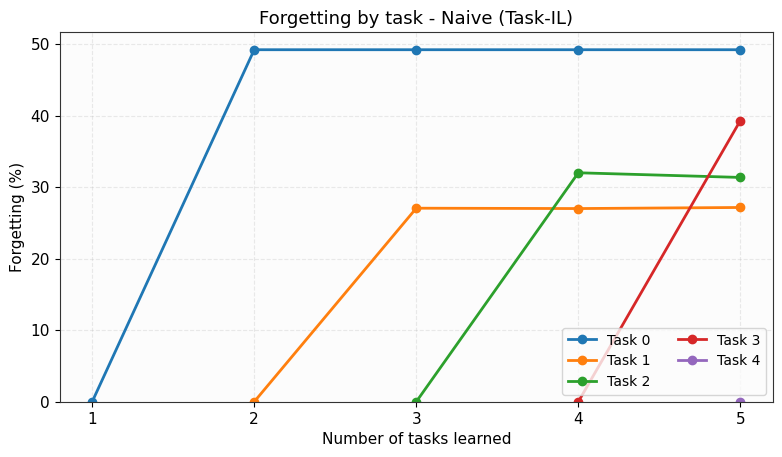

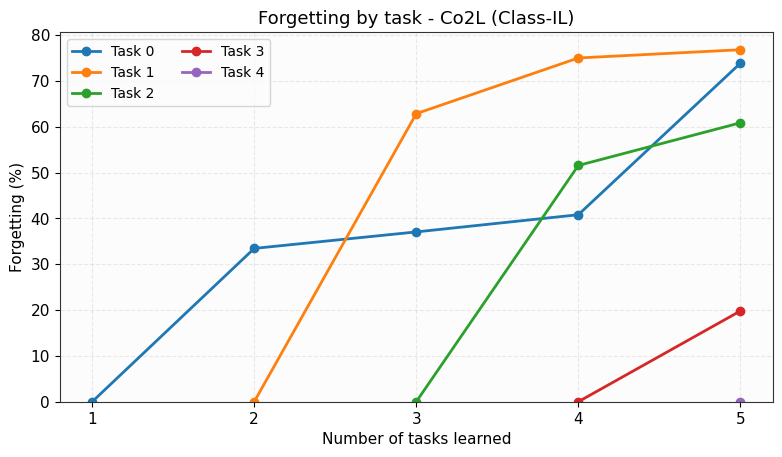

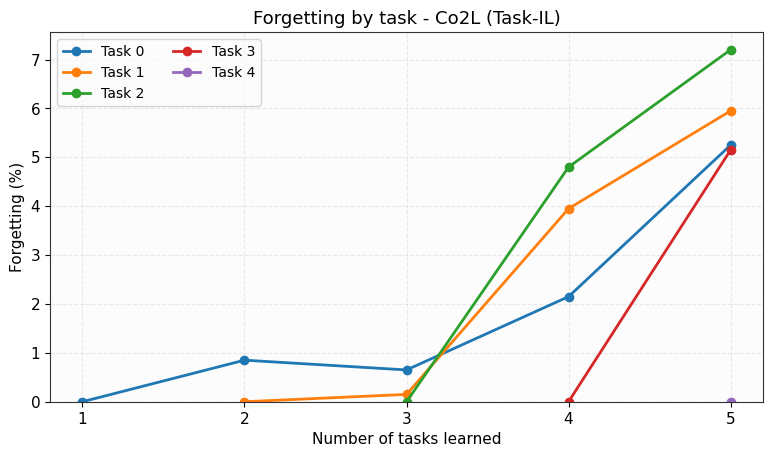

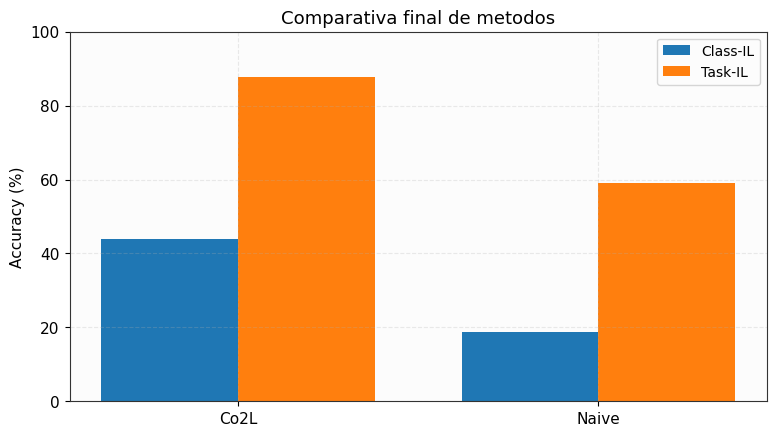

Saved comparison plot: outputs/imgs/methods_comparison.png


In [9]:
import csv
import matplotlib.pyplot as plt

method_histories = {}

if "naive_history" in globals():
    method_histories["Naive"] = naive_history
if "ewc_history" in globals():
    method_histories["EWC"] = ewc_history
if "lwf_history" in globals():
    method_histories["LwF"] = lwf_history
if "co2l_history" in globals():
    method_histories["Co2L"] = co2l_history
if "er_ace_history" in globals():
    method_histories["ER-ACE"] = er_ace_history

if not method_histories:
    raise RuntimeError("No se encontraron historiales. Ejecuta primero las secciones de entrenamiento.")

summary = []
for method_name, hist in method_histories.items():
    class_il = float(hist["class_il"][-1])
    task_il = float(hist["task_il"][-1])
    summary.append({
        "method": method_name,
        "final_class_il": class_il,
        "final_task_il": task_il,
    })

summary = sorted(summary, key=lambda r: r["final_class_il"], reverse=True)

print("Comparativa final (ordenado por Class-IL):")
print("-" * 56)
print("{:<12} {:>12} {:>12}".format("Metodo", "Class-IL", "Task-IL"))
print("-" * 56)
for row in summary:
    print("{:<12} {:>11.2f}% {:>11.2f}%".format(row["method"], row["final_class_il"], row["final_task_il"]))

metrics_dir = Path(cfg.outputs.root) / "metrics"
metrics_dir.mkdir(parents=True, exist_ok=True)

# Unified final table
csv_path = metrics_dir / "methods_comparison.csv"
with csv_path.open("w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=["method", "final_class_il", "final_task_il"])
    writer.writeheader()
    writer.writerows(summary)
print(f"Saved metrics table: {csv_path}")

# Required plot from consigna: all methods over tasks
plot_methods_over_tasks(
    histories_by_method=method_histories,
    save_path=Path(cfg.outputs.root) / "imgs" / "methods_over_tasks.png",
)

# Optional forgetting curves for both Class-IL and Task-IL
plot_forgetting_curves(
    histories_by_method=method_histories,
    metric="class_il",
    save_path=Path(cfg.outputs.root) / "imgs" / "forgetting_class_il.png",
)
plot_forgetting_curves(
    histories_by_method=method_histories,
    metric="task_il",
    save_path=Path(cfg.outputs.root) / "imgs" / "forgetting_task_il.png",
)


# Per-method forgetting by task (optional detailed view)
for method_name, hist in method_histories.items():
    safe_name = method_name.lower().replace(" ", "_").replace("-", "_")
    plot_forgetting_by_task(
        history=hist,
        method_name=method_name,
        metric="class_il",
        save_path=Path(cfg.outputs.root) / "imgs" / f"forgetting_by_task_class_il_{safe_name}.png",
    )
    plot_forgetting_by_task(
        history=hist,
        method_name=method_name,
        metric="task_il",
        save_path=Path(cfg.outputs.root) / "imgs" / f"forgetting_by_task_task_il_{safe_name}.png",
    )
# Keep final bar chart for quick summary
methods = [r["method"] for r in summary]
class_vals = [r["final_class_il"] for r in summary]
task_vals = [r["final_task_il"] for r in summary]
x = range(len(methods))
w = 0.38
fig = plt.figure(figsize=(9, 4.8))
plt.bar([k - w / 2 for k in x], class_vals, width=w, label="Class-IL")
plt.bar([k + w / 2 for k in x], task_vals, width=w, label="Task-IL")
plt.xticks(list(x), methods)
plt.ylim(0, 100)
plt.ylabel("Accuracy (%)")
plt.title("Comparativa final de metodos")
plt.grid(axis="y", alpha=0.25)
plt.legend()
plot_path = Path(cfg.outputs.root) / "imgs" / "methods_comparison.png"
plot_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved comparison plot: {plot_path}")
